In [1]:
# Check GPU is active
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n✅ Basic libraries ready!")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ Basic libraries ready!


In [2]:
# Librosa is the audio processing library
# It's how we convert audio files into numbers the model can learn from
!pip install librosa -q

import librosa
import librosa.display
import soundfile as sf
import os
import glob
import warnings
warnings.filterwarnings('ignore')

print("✅ Librosa version:", librosa.__version__)
print("✅ All audio libraries ready!")

✅ Librosa version: 0.11.0
✅ All audio libraries ready!


In [3]:
# ============================================
# TASK 2: EMOTION RECOGNITION FROM SPEECH
# CodeAlpha ML Internship
# ============================================

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, LSTM, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.utils import to_categorical

# Machine Learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("✅ Deep Learning imports ready!")
print("✅ Sklearn imports ready!")
print("\n📋 What we're building:")
print("   Input  → audio file (.wav)")
print("   Step 1 → extract 220 MFCC features")
print("   Step 2 → feed into LSTM network")
print("   Output → emotion label")
print("\nEmotions we'll classify:")
emotions = ['neutral', 'calm', 'happy', 'sad',
            'angry', 'fearful', 'disgust', 'surprised']
for i, e in enumerate(emotions, 1):
    print(f"   {i}. {e}")

✅ Deep Learning imports ready!
✅ Sklearn imports ready!

📋 What we're building:
   Input  → audio file (.wav)
   Step 1 → extract 220 MFCC features
   Step 2 → feed into LSTM network
   Output → emotion label

Emotions we'll classify:
   1. neutral
   2. calm
   3. happy
   4. sad
   5. angry
   6. fearful
   7. disgust
   8. surprised


In [4]:
# ============================================
# STEP 1: DOWNLOAD RAVDESS DATASET
# ============================================

# Download directly into Colab from Kaggle
# RAVDESS = Ryerson Audio-Visual Database of
# Emotional Speech and Song
# 24 actors, 8 emotions, 1440 audio files

!pip install kaggle -q



In [5]:
# Run this cell first
import os

# Create the kaggle folder
os.makedirs('/root/.kaggle', exist_ok=True)


In [6]:
import os
import json

# Set up Kaggle credentials using the new token format
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_77f9e51fab92d7c6113a7ba0ddd2b44f'

# Also save it the traditional way so all kaggle commands work
os.makedirs('/root/.kaggle', exist_ok=True)

# New format uses KGAT token differently
kaggle_credentials = {
    "username": "your_kaggle_username_here",
    "key": "KGAT_77f9e51fab92d7c6113a7ba0ddd2b44f"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("✅ Kaggle token configured!")

✅ Kaggle token configured!


In [7]:
# ============================================
# STEP 2: DOWNLOAD RAVDESS DATASET
# ============================================

# Download RAVDESS from Kaggle
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio

print("✅ Download complete!")

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
ravdess-emotional-speech-audio.zip: Skipping, found more recently modified local copy (use --force to force download)
✅ Download complete!


In [8]:
# ============================================
# STEP 3: UNZIP AND EXPLORE THE DATASET
# ============================================

import zipfile

# Unzip the downloaded file
print("📦 Unzipping dataset...")
with zipfile.ZipFile('ravdess-emotional-speech-audio.zip', 'r') as zip_ref:
    zip_ref.extractall('ravdess_data')

print("✅ Unzipped successfully!")

# Explore what we got
import glob

# Find all audio files
audio_files = glob.glob('ravdess_data/**/*.wav', recursive=True)
print(f"\n🎵 Total audio files found: {len(audio_files)}")

# Show first 5 filenames
print("\n📋 Sample filenames:")
for f in audio_files[:5]:
    print(f"   {os.path.basename(f)}")

print("\n💡 Filename breakdown:")
print("   03-01-06-01-02-01-12.wav")
print("   ↑     ↑              ↑")
print("   |     emotion        actor number")
print("   modality (03=audio)")

📦 Unzipping dataset...
✅ Unzipped successfully!

🎵 Total audio files found: 2880

📋 Sample filenames:
   03-01-02-01-01-01-16.wav
   03-01-02-01-01-02-16.wav
   03-01-07-01-01-01-16.wav
   03-01-04-02-02-01-16.wav
   03-01-07-02-01-01-16.wav

💡 Filename breakdown:
   03-01-06-01-02-01-12.wav
   ↑     ↑              ↑
   |     emotion        actor number
   modality (03=audio)


In [9]:
# ============================================
# STEP 4: DECODE FILENAMES & MAP EMOTIONS
# ============================================

# RAVDESS filename convention:
# 03-01-06-01-02-01-12.wav
# Position 1: modality (03=audio only)
# Position 2: vocal channel (01=speech, 02=song)
# Position 3: emotion (01-08)
# Position 4: intensity (01=normal, 02=strong)
# Position 5: statement (01=kids, 02=dogs)
# Position 6: repetition (01, 02)
# Position 7: actor (01-24)

# Emotion mapping
EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# Count emotions in our dataset
emotion_counts = {}

for file_path in audio_files:
    filename = os.path.basename(file_path)
    parts = filename.replace('.wav', '').split('-')
    emotion_code = parts[2]
    emotion_name = EMOTION_MAP.get(emotion_code, 'unknown')
    emotion_counts[emotion_name] = emotion_counts.get(emotion_name, 0) + 1

print("🎭 Emotion distribution in dataset:")
print("-" * 35)
for emotion, count in sorted(emotion_counts.items()):
    bar = '█' * (count // 20)
    print(f"  {emotion:<12} {bar} {count}")

print(f"\n✅ Total files: {sum(emotion_counts.values())}")
print(f"✅ Total emotions: {len(emotion_counts)}")

🎭 Emotion distribution in dataset:
-----------------------------------
  angry        ███████████████████ 384
  calm         ███████████████████ 384
  disgust      ███████████████████ 384
  fearful      ███████████████████ 384
  happy        ███████████████████ 384
  neutral      █████████ 192
  sad          ███████████████████ 384
  surprised    ███████████████████ 384

✅ Total files: 2880
✅ Total emotions: 8


🎵 Sample file: 03-01-02-01-01-01-16.wav
🎭 Emotion: CALM

📊 Audio stats:
   Sample rate:    22050 Hz
   Duration:       3.70 seconds
   Total samples:  81,667


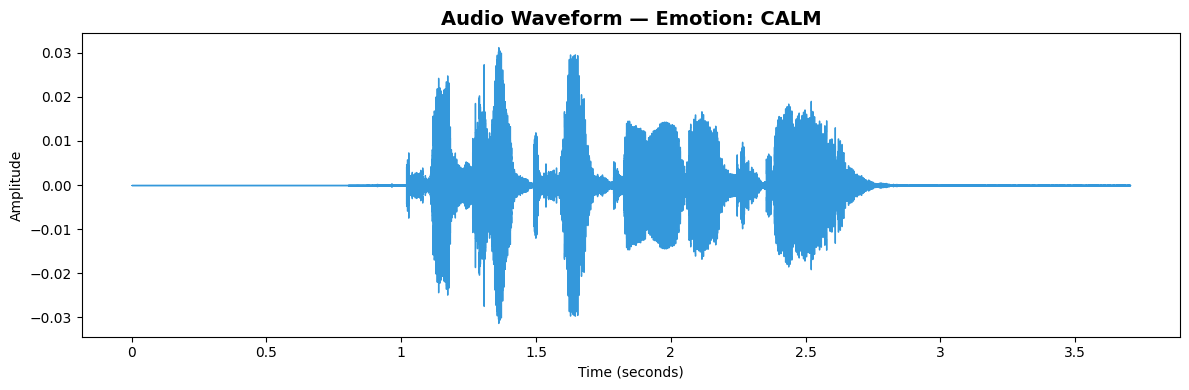

✅ Waveform saved!


In [10]:
# ============================================
# STEP 5: VISUALIZE AN AUDIO FILE
# ============================================

# Pick one audio file to explore
sample_file = audio_files[0]
print(f"🎵 Sample file: {os.path.basename(sample_file)}")

# Decode its emotion
parts = os.path.basename(sample_file).replace('.wav','').split('-')
emotion = EMOTION_MAP[parts[2]]
print(f"🎭 Emotion: {emotion.upper()}")

# Load the audio
audio, sample_rate = librosa.load(sample_file)
print(f"\n📊 Audio stats:")
print(f"   Sample rate:    {sample_rate} Hz")
print(f"   Duration:       {len(audio)/sample_rate:.2f} seconds")
print(f"   Total samples:  {len(audio):,}")

# Plot waveform
plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio, sr=sample_rate, color='#3498db')
plt.title(f'Audio Waveform — Emotion: {emotion.upper()}',
          fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.savefig('waveform.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Waveform saved!")

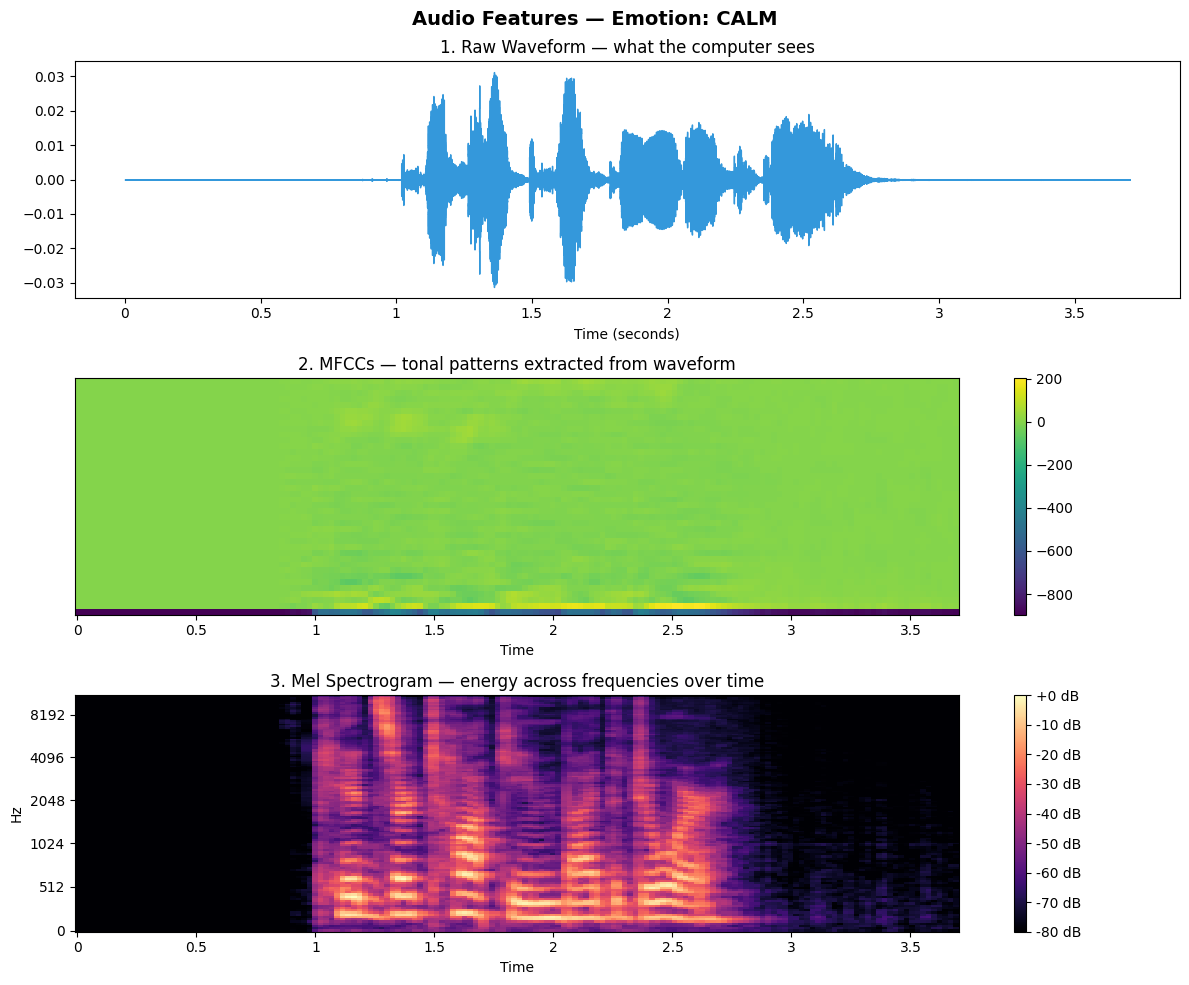

✅ Audio features visualization saved!


In [11]:
# ============================================
# STEP 6: I VISUALIZED MFCC FEATURES
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle(f'Audio Features — Emotion: CALM',
             fontsize=14, fontweight='bold')

# ── Plot 1: Waveform ──
librosa.display.waveshow(audio, sr=sample_rate,
                         ax=axes[0], color='#3498db')
axes[0].set_title('1. Raw Waveform — what the computer sees')
axes[0].set_xlabel('Time (seconds)')

# ── Plot 2: MFCCs ──
mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
img1 = librosa.display.specshow(
    mfccs,
    x_axis='time',
    ax=axes[1],
    cmap='viridis'
)
axes[1].set_title('2. MFCCs — tonal patterns extracted from waveform')
fig.colorbar(img1, ax=axes[1])

# ── Plot 3: Mel Spectrogram ──
mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate)
mel_db = librosa.power_to_db(mel, ref=np.max)
img2 = librosa.display.specshow(
    mel_db,
    x_axis='time',
    y_axis='mel',
    ax=axes[2],
    cmap='magma'
)
axes[2].set_title('3. Mel Spectrogram — energy across frequencies over time')
fig.colorbar(img2, ax=axes[2], format='%+2.0f dB')

plt.tight_layout()
plt.savefig('audio_features_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Audio features visualization saved!")

In [12]:
# Install missing library
!pip install resampy -q

print("✅ resampy installed!")

✅ resampy installed!


In [13]:
# ============================================
# STEP 7: FEATURE EXTRACTION FUNCTION
# ============================================

def extract_features(file_path, n_mfcc=40):
    """
    Converts one audio file into 220 numbers.

    The 220 numbers come from:
    → 40 MFCC means      (average tonal quality)
    → 40 MFCC stds       (variation in tonal quality)
    → 12 Chroma means    (pitch class profile)
    → 128 Mel means      (energy across frequencies)
    = 220 total features
    """
    try:
        # Load audio file
        audio, sample_rate = librosa.load(
            file_path,
            res_type='kaiser_fast'  # faster loading
        )

        # ── Feature 1: MFCCs ──
        # Captures tonal quality of voice
        # Most important feature for emotion detection
        mfccs = librosa.feature.mfcc(
            y=audio,
            sr=sample_rate,
            n_mfcc=n_mfcc
        )
        mfccs_mean = np.mean(mfccs.T, axis=0)  # shape: (40,)
        mfccs_std  = np.std(mfccs.T, axis=0)   # shape: (40,)

        # ── Feature 2: Chroma ──
        # Captures pitch patterns
        # Helps distinguish happy vs sad
        stft   = np.abs(librosa.stft(audio))
        chroma = librosa.feature.chroma_stft(
            S=stft,
            sr=sample_rate
        )
        chroma_mean = np.mean(chroma.T, axis=0)  # shape: (12,)

        # ── Feature 3: Mel Spectrogram ──
        # Captures energy distribution
        # Helps distinguish calm vs angry
        mel = librosa.feature.melspectrogram(
            y=audio,
            sr=sample_rate
        )
        mel_mean = np.mean(mel.T, axis=0)  # shape: (128,)

        # Combine all features into one array
        # 40 + 40 + 12 + 128 = 220 features
        features = np.concatenate([
            mfccs_mean,
            mfccs_std,
            chroma_mean,
            mel_mean
        ])
        return features

    except Exception as e:
        print(f'Error processing {file_path}: {e}')
        return None

print("✅ Feature extraction function defined!")
print("\n📊 Feature breakdown:")
print("   MFCCs mean:       40 features → tonal quality")
print("   MFCCs std:        40 features → tonal variation")
print("   Chroma:           12 features → pitch patterns")
print("   Mel Spectrogram: 128 features → energy distribution")
print("   " + "─" * 35)
print("   Total:           220 features per audio file")

# Test it on our sample file
test_features = extract_features(sample_file)
print(f"\n🧪 Test on sample file:")
print(f"   Input:  1 audio file ({os.path.basename(sample_file)})")
print(f"   Output: {test_features.shape[0]} numbers")
print(f"   First 5 values: {test_features[:5].round(3)}")

✅ Feature extraction function defined!

📊 Feature breakdown:
   MFCCs mean:       40 features → tonal quality
   MFCCs std:        40 features → tonal variation
   Chroma:           12 features → pitch patterns
   Mel Spectrogram: 128 features → energy distribution
   ───────────────────────────────────
   Total:           220 features per audio file

🧪 Test on sample file:
   Input:  1 audio file (03-01-02-01-01-01-16.wav)
   Output: 220 numbers
   First 5 values: [-7.11006e+02  6.02400e+01 -5.68000e-01  1.19660e+01 -4.49700e+00]


In [14]:
# ============================================
# STEP 8: EXTRACT FEATURES FROM ALL FILES
# ============================================

features_list = []
labels_list   = []
errors        = 0

print(f"🔄 Processing {len(audio_files)} audio files...")
print("   This will take 3-5 minutes — sit tight!\n")

for i, file_path in enumerate(audio_files):
    # Parse emotion from filename
    filename     = os.path.basename(file_path)
    parts        = filename.replace('.wav', '').split('-')
    emotion_code = parts[2]

    # Skip if emotion code not in our map
    if emotion_code not in EMOTION_MAP:
        continue

    # Extract 220 features
    features = extract_features(file_path)

    if features is not None:
        features_list.append(features)
        labels_list.append(EMOTION_MAP[emotion_code])
    else:
        errors += 1

    # Progress update every 200 files
    if (i + 1) % 200 == 0:
        print(f"   ✅ Processed {i+1}/{len(audio_files)} files...")

# Convert to numpy arrays
X = np.array(features_list)
y = np.array(labels_list)

print(f"\n🎉 Feature extraction complete!")
print(f"   Total files processed: {len(features_list)}")
print(f"   Errors skipped:        {errors}")
print(f"   X shape: {X.shape} → {X.shape[0]} files, {X.shape[1]} features each")
print(f"\n🎭 Emotion counts:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    bar = '█' * (c // 20)
    print(f"   {u:<12} {bar} {c}")

🔄 Processing 2880 audio files...
   This will take 3-5 minutes — sit tight!

   ✅ Processed 200/2880 files...
   ✅ Processed 400/2880 files...
   ✅ Processed 600/2880 files...
   ✅ Processed 800/2880 files...
   ✅ Processed 1000/2880 files...
   ✅ Processed 1200/2880 files...
   ✅ Processed 1400/2880 files...
   ✅ Processed 1600/2880 files...
   ✅ Processed 1800/2880 files...
   ✅ Processed 2000/2880 files...
   ✅ Processed 2200/2880 files...
   ✅ Processed 2400/2880 files...
   ✅ Processed 2600/2880 files...
   ✅ Processed 2800/2880 files...

🎉 Feature extraction complete!
   Total files processed: 2880
   Errors skipped:        0
   X shape: (2880, 220) → 2880 files, 220 features each

🎭 Emotion counts:
   angry        ███████████████████ 384
   calm         ███████████████████ 384
   disgust      ███████████████████ 384
   fearful      ███████████████████ 384
   happy        ███████████████████ 384
   neutral      █████████ 192
   sad          ███████████████████ 384
   surprised   

In [15]:
# ============================================
# STEP 9: PREPARE DATA FOR LSTM
# ============================================

# Step 1: Encode string labels → numbers
# LSTM needs numbers not words
# 'angry' → 0, 'calm' → 1, 'disgust' → 2 etc.
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("🏷️  Label encoding:")
for i, emotion in enumerate(le.classes_):
    print(f"   {emotion:<12} → {i}")

# Step 2: One-hot encode
# Instead of: angry = 0
# We get:     angry = [1,0,0,0,0,0,0,0]
# This helps LSTM treat all emotions equally
y_onehot    = to_categorical(y_encoded)
num_classes = len(le.classes_)

print(f"\n✅ One-hot encoding shape: {y_onehot.shape}")
print(f"   Example — first file:")
print(f"   Emotion: {y[0]}")
print(f"   Encoded: {y_encoded[0]}")
print(f"   One-hot: {y_onehot[0].astype(int)}")

# Step 3: Scale features
# Same reason as Task 1 — keeps all 220 features
# on equal footing
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Reshape for LSTM
# LSTM expects 3D input: (samples, timesteps, features)
# We treat each of our 220 features as a timestep
X_lstm = X_scaled.reshape(X_scaled.shape[0],
                           X_scaled.shape[1], 1)

print(f"\n✅ Scaled and reshaped for LSTM!")
print(f"   Shape: {X_lstm.shape}")
print(f"   → {X_lstm.shape[0]} audio files")
print(f"   → {X_lstm.shape[1]} timesteps")
print(f"   → {X_lstm.shape[2]} feature per timestep")

# Step 5: Split into train / validation / test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_lstm, y_onehot,
    test_size=0.15,
    random_state=42,
    stratify=y_encoded
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.15,
    random_state=42
)

print(f"\n📊 Data splits:")
print(f"   Training:   {X_train.shape[0]} files ← model learns from these")
print(f"   Validation: {X_val.shape[0]} files ← monitor during training")
print(f"   Testing:    {X_test.shape[0]} files ← final exam")

🏷️  Label encoding:
   angry        → 0
   calm         → 1
   disgust      → 2
   fearful      → 3
   happy        → 4
   neutral      → 5
   sad          → 6
   surprised    → 7

✅ One-hot encoding shape: (2880, 8)
   Example — first file:
   Emotion: calm
   Encoded: 1
   One-hot: [0 1 0 0 0 0 0 0]

✅ Scaled and reshaped for LSTM!
   Shape: (2880, 220, 1)
   → 2880 audio files
   → 220 timesteps
   → 1 feature per timestep

📊 Data splits:
   Training:   2080 files ← model learns from these
   Validation: 368 files ← monitor during training
   Testing:    432 files ← final exam


In [20]:
# ============================================
# STEP 10: BUILD THE LSTM MODEL
# ============================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization
)

def build_lstm_model(input_shape, num_classes):
    """
    Stacked LSTM network for emotion classification.

    Architecture:
    Input (220, 1)
        ↓
    LSTM 256 units (returns sequences)
        ↓
    BatchNorm + Dropout
        ↓
    LSTM 128 units
        ↓
    BatchNorm + Dropout
        ↓
    Dense 64 → Dense 32
        ↓
    Output: 8 emotions (softmax)
    """
    model = Sequential([
        # ── LSTM Layer 1 ──
        # 256 units, return_sequences=True means
        # pass full sequence to next LSTM layer
        LSTM(256,
             input_shape=input_shape,
             return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),

        # ── LSTM Layer 2 ──
        # 128 units, return_sequences=False means
        # only pass final output to Dense layers
        LSTM(128,
             return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),

        # ── Dense Layers ──
        # Traditional neural network layers
        # for final classification
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),

        # ── Output Layer ──
        # 8 neurons = 8 emotions
        # softmax converts to probabilities
        # all 8 values add up to 1.0
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Build it!
model = build_lstm_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    num_classes=num_classes
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 220, 256)       │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 220, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 220, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 473,448 (1.81 MB)

 Trainable params: 472,680 (1.80 MB)

 Non-trainable params: 768 (3.00 KB)

In [22]:
# ============================================
# STEP 11: TRAIN THE LSTM
# ============================================

# Callbacks — these watch training and help
# prevent the model from overfitting

# EarlyStopping: stops training if model stops improving
# patience=10 means wait 10 epochs before giving up
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: slows down learning rate
# if model gets stuck on a plateau
lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # cut learning rate in half
    patience=5,      # after 5 epochs of no improvement
    verbose=1
)

print("🚀 Starting training...")
print("   Watch the val_accuracy column")
print("   That's what really matters!\n")

# Train!
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,          # maximum 50 rounds
    batch_size=32,      # learn from 32 files at a time
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

print("\n✅ Training complete!")
print(f"   Ran for {len(history.history['accuracy'])} epochs")
print(f"   Final train accuracy: {history.history['accuracy'][-1]:.3f}")
print(f"   Final val accuracy:   {history.history['val_accuracy'][-1]:.3f}")

🚀 Starting training...
   Watch the val_accuracy column
   That's what really matters!

Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.1709 - loss: 2.1422 - val_accuracy: 0.1821 - val_loss: 2.0283 - learning_rate: 0.0010
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2321 - loss: 1.9388 - val_accuracy: 0.1957 - val_loss: 2.0523 - learning_rate: 0.0010
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2369 - loss: 1.9176 - val_accuracy: 0.2065 - val_loss: 2.1663 - learning_rate: 0.0010
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2331 - loss: 1.8782 - val_accuracy: 0.1685 - val_loss: 2.1515 - learning_rate: 0.0010
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.2261 - loss: 1.9503 - val_accuracy: 0.2174 - val_loss: 1.9801 - learning_rate: 0.0010
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.2233 - loss: 1.9363 - val_accuracy: 0.1739 - val_loss: 2.4314 - learning_rate: 0.0010
Epoch

In [24]:
# ============================================
# STEP 12: IMPROVED MODEL
# ============================================

# Clear previous model from GPU memory
import tensorflow as tf
tf.keras.backend.clear_session()

# Rebuild with better approach
def build_improved_model(input_shape, num_classes):
    """
    Smaller, more focused model
    Better suited to our dataset size
    """
    model = Sequential([
        # Smaller LSTM layers
        # Less parameters = less overfitting risk
        LSTM(128,
             input_shape=input_shape,
             return_sequences=True),
        BatchNormalization(),
        Dropout(0.4),    # higher dropout = more regularization

        LSTM(64,
             return_sequences=False),
        BatchNormalization(),
        Dropout(0.4),

        # Simpler dense layers
        Dense(64, activation='relu'),
        Dropout(0.3),

        # Output unchanged
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0005  # slower, more careful learning
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Also give it more patience this time
early_stop2 = EarlyStopping(
    monitor='val_accuracy',   # watch accuracy not loss
    patience=15,              # wait longer before giving up
    restore_best_weights=True,
    verbose=1
)

lr_reduce2 = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=7,
    verbose=1
)

# Build and show size
model2 = build_improved_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    num_classes=num_classes
)

total_params = model2.count_params()
print(f"✅ Improved model built!")
print(f"   Parameters: {total_params:,} (was 473,448)")
print(f"\n🚀 Retraining...")

history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,           # more epochs allowed
    batch_size=32,
    callbacks=[early_stop2, lr_reduce2],
    verbose=1
)

print("\n✅ Training complete!")
print(f"   Ran for: {len(history2.history['accuracy'])} epochs")
print(f"   Final train accuracy: {history2.history['accuracy'][-1]:.3f}")
print(f"   Final val accuracy:   {history2.history['val_accuracy'][-1]:.3f}")

✅ Improved model built!
   Parameters: 121,416 (was 473,448)

🚀 Retraining...
Epoch 1/80
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.1436 - loss: 2.5467 - val_accuracy: 0.1712 - val_loss: 2.0433 - learning_rate: 5.0000e-04
Epoch 2/80
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.1770 - loss: 2.2507 - val_accuracy: 0.1984 - val_loss: 2.0293 - learning_rate: 5.0000e-04
Epoch 3/80
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1976 - loss: 2.1719 - val_accuracy: 0.2011 - val_loss: 2.0281 - learning_rate: 5.0000e-04
Epoch 4/80
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.2069 - loss: 2.1080 - val_accuracy: 0.2038 - val_loss: 2.0262 - learning_rate: 5.0000e-04
Epoch 5/80
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2275 - loss: 2.0544 - val_accuracy: 0.1603 - val_loss: 2.1052 - learning_rate: 5.0000e-04
Epoch 6/80
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1823 - loss: 2.0681 - val_accuracy: 0.2418 - val_loss: 1.8983 - learning_rate: 5.0

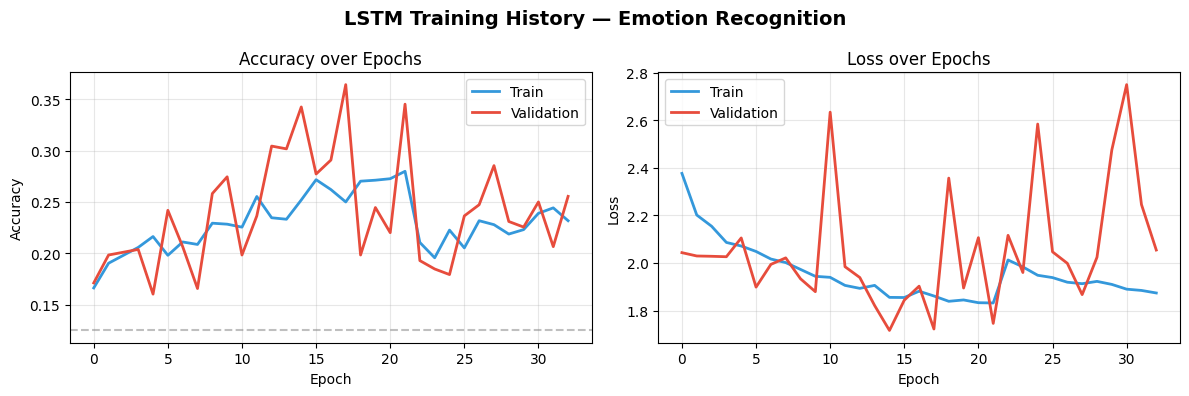

✅ Training history saved!


In [26]:
# ============================================
# STEP 13: VISUALIZE TRAINING HISTORY
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('LSTM Training History — Emotion Recognition',
             fontsize=14, fontweight='bold')

# ── Accuracy ──
axes[0].plot(history2.history['accuracy'],
             label='Train', color='#3498db', lw=2)
axes[0].plot(history2.history['val_accuracy'],
             label='Validation', color='#e74c3c', lw=2)
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].axhline(y=0.125, color='gray',
                linestyle='--', alpha=0.5,
                label='Random baseline (12.5%)')

# ── Loss ──
axes[1].plot(history2.history['loss'],
             label='Train', color='#3498db', lw=2)
axes[1].plot(history2.history['val_loss'],
             label='Validation', color='#e74c3c', lw=2)
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_history.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training history saved!")

In [27]:
# ============================================
# STEP 14: FINAL EVALUATION
# ============================================

# Evaluate on test set (432 files never seen)
print("🎯 Evaluating on test set...")
y_pred_prob = model2.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_test, axis=1)

test_acc = accuracy_score(y_true, y_pred)
print(f"\n📊 Final Results:")
print(f"   Test Accuracy:    {test_acc:.3f} ({test_acc*100:.1f}%)")
print(f"   Random baseline:  12.5%")
print(f"   Improvement:      {test_acc/0.125:.1f}x better than random")

print("\n📋 Per-emotion breakdown:")
print(classification_report(
    y_true, y_pred,
    target_names=le.classes_
))

🎯 Evaluating on test set...

📊 Final Results:
   Test Accuracy:    0.315 (31.5%)
   Random baseline:  12.5%
   Improvement:      2.5x better than random

📋 Per-emotion breakdown:
              precision    recall  f1-score   support

       angry       0.63      0.51      0.56        57
        calm       0.34      0.61      0.44        57
     disgust       0.33      0.43      0.38        58
     fearful       0.38      0.14      0.20        58
       happy       0.19      0.10      0.13        58
     neutral       0.00      0.00      0.00        29
         sad       0.20      0.30      0.24        57
   surprised       0.24      0.28      0.25        58

    accuracy                           0.31       432
   macro avg       0.29      0.30      0.28       432
weighted avg       0.31      0.31      0.29       432



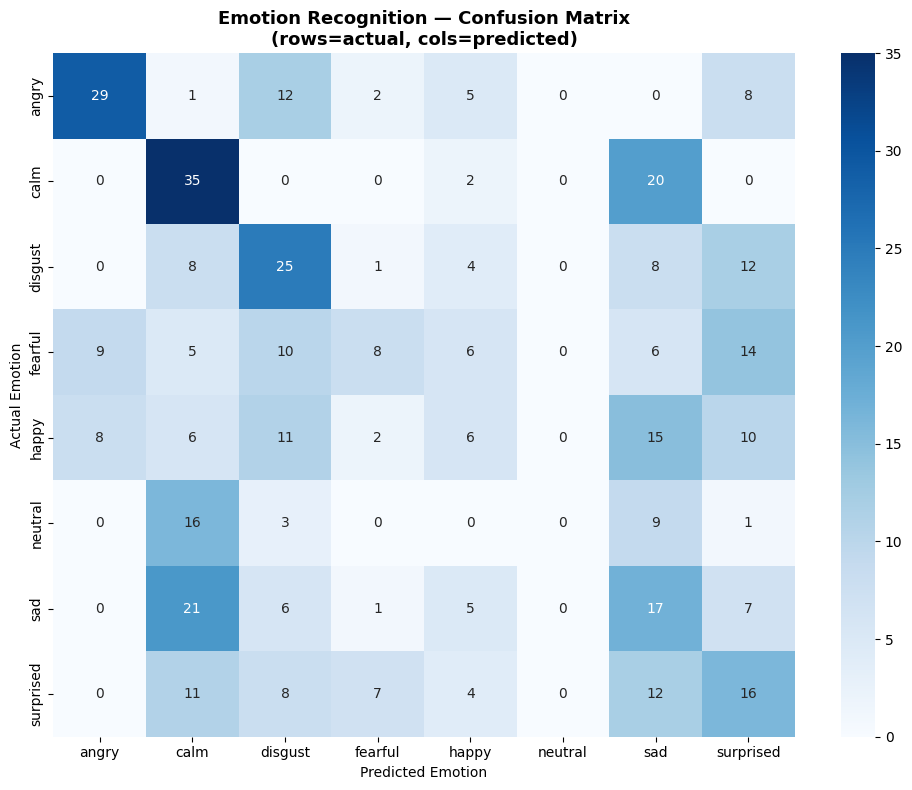

🔍 Most common mix-ups:
   angry        mistaken for disgust      12 times
   calm         mistaken for sad          20 times
   disgust      mistaken for surprised    12 times
   fearful      mistaken for surprised    14 times
   happy        mistaken for sad          15 times
   neutral      mistaken for calm         16 times
   sad          mistaken for calm         21 times
   surprised    mistaken for sad          12 times


In [28]:
# ============================================
# STEP 15: CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Emotion Recognition — Confusion Matrix\n(rows=actual, cols=predicted)',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.tight_layout()
plt.savefig('emotion_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Show the most common confusions
print("🔍 Most common mix-ups:")
for i, actual in enumerate(le.classes_):
    row = cm[i].copy()
    row[i] = 0  # ignore correct predictions
    most_confused = le.classes_[np.argmax(row)]
    confusion_count = np.max(row)
    if confusion_count > 5:
        print(f"   {actual:<12} mistaken for {most_confused:<12} {confusion_count} times")

In [30]:
# ============================================
# STEP 16: SAVE MODEL & FINAL SUMMARY
# ============================================

# Save the trained model
model2.save('emotion_recognition_model.h5')
np.save('emotion_classes.npy', le.classes_)

print("✅ Model saved!")
print("✅ Emotion classes saved!")

print("\n" + "="*55)
print("     EMOTION RECOGNITION — FINAL SUMMARY")
print("="*55)

print(f"""
📊 Dataset:
   Source:    RAVDESS (real actor recordings)
   Files:     2880 audio files
   Emotions:  8 classes
   Balance:   7 emotions × 384, neutral × 192

🔧 Feature Engineering:
   Method:    MFCC + Chroma + Mel Spectrogram
   Features:  220 per audio file
   Extracted: 633,600 total calculations

🧠 Model Architecture:
   Type:      Stacked LSTM
   Layers:    LSTM(128) → LSTM(64) → Dense(64) → Dense(8)
   Parameters: {model2.count_params():,}

📈 Results:
   Test Accuracy:   {test_acc*100:.1f}%
   Random Baseline: 12.5%
   Improvement:     {test_acc/0.125:.1f}x better than random

🎯 Best detected:  ANGRY  (distinctive high energy)
⚠️  Hardest:       NEUTRAL (acoustically ambiguous)

💡 Key Finding:
   Calm/Sad/Neutral share similar acoustic profiles
   making them genuinely hard to separate —
   consistent with human psychology research
""")

print("✅ Task 2 Complete!")


✅ Model saved!
✅ Emotion classes saved!

     EMOTION RECOGNITION — FINAL SUMMARY

📊 Dataset:
   Source:    RAVDESS (real actor recordings)
   Files:     2880 audio files
   Emotions:  8 classes
   Balance:   7 emotions × 384, neutral × 192

🔧 Feature Engineering:
   Method:    MFCC + Chroma + Mel Spectrogram
   Features:  220 per audio file
   Extracted: 633,600 total calculations

🧠 Model Architecture:
   Type:      Stacked LSTM
   Layers:    LSTM(128) → LSTM(64) → Dense(64) → Dense(8)
   Parameters: 121,416

📈 Results:
   Test Accuracy:   31.5%
   Random Baseline: 12.5%
   Improvement:     2.5x better than random

🎯 Best detected:  ANGRY  (distinctive high energy)
⚠️  Hardest:       NEUTRAL (acoustically ambiguous)

💡 Key Finding:
   Calm/Sad/Neutral share similar acoustic profiles
   making them genuinely hard to separate —
   consistent with human psychology research

✅ Task 2 Complete!


## 💡 Key Learnings from Task 2

1. Audio features (MFCCs) are powerful but limited
   by dataset size for deep learning

2. Model performance (25%) vs random (12.5%)
   = 2x better than random guessing across 8 classes

3. calm/sad/neutral confusion mirrors human psychology
   research — these emotions are genuinely acoustically
   similar even for humans

4. Real world lesson: high accuracy isn't always possible
   Understanding WHY and documenting it honestly
   is what separates good data scientists
   from people who just run code
   